<a href="https://colab.research.google.com/github/sametgumusaydin/data_mining-AI/blob/main/data_mining_DBScan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Veri seti
data = {
    "gelir": [32000, 45000, 58000, 62000, 29000, 70000, 52000, 81000, 47000, 90000,
              61000, 38000, 55000, 73000, 34000, 68000, 49000, 76000, 43000, 64000,
              57000, 36000, 85000, 51000],
    "yas": [22, 25, 27, 30, 21, 35, 28, 40, 26, 45,
            31, 24, 29, 38, 23, 34, 27, 39, 25, 33,
            30, 22, 42, 28],
    "mevcut_borc": [18000, 12000, 10000, 9000, 15000, 8000, 14000, 5000, 11000, 4000,
                    9500, 17000, 13000, 6000, 16000, 7000, 12500, 5500, 14500, 8500,
                    10000, 17500, 4500, 13500],
    "kredi_puani": [480, 520, 610, 640, 450, 700, 590, 760, 560, 790,
                    650, 500, 600, 720, 490, 690, 570, 740, 530, 660,
                    620, 470, 780, 585],
    "sonuc": [0, 0, 1, 1, 0, 1, 0, 1, 0, 1,
              1, 0, 1, 1, 0, 1, 0, 1, 0, 1,
              1, 0, 1, 0]
}

df = pd.DataFrame(data)

# Görselleştirme için 2 özellik seçiyoruz
X = df[["gelir", "kredi_puani"]].values

# Ölçekleme (DBSCAN için KRİTİK)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# DBSCAN modeli
dbscan = DBSCAN(eps=0.4, min_samples=3)
labels = dbscan.fit_predict(X_scaled)

# Sonuçları ekle
df["cluster"] = labels

print(df)

    gelir  yas  mevcut_borc  kredi_puani  sonuc  cluster
0   32000   22        18000          480      0        0
1   45000   25        12000          520      0        1
2   58000   27        10000          610      1        1
3   62000   30         9000          640      1        1
4   29000   21        15000          450      0        0
5   70000   35         8000          700      1        1
6   52000   28        14000          590      0        1
7   81000   40         5000          760      1        1
8   47000   26        11000          560      0        1
9   90000   45         4000          790      1        1
10  61000   31         9500          650      1        1
11  38000   24        17000          500      0        0
12  55000   29        13000          600      1        1
13  73000   38         6000          720      1        1
14  34000   23        16000          490      0        0
15  68000   34         7000          690      1        1
16  49000   27        12500    

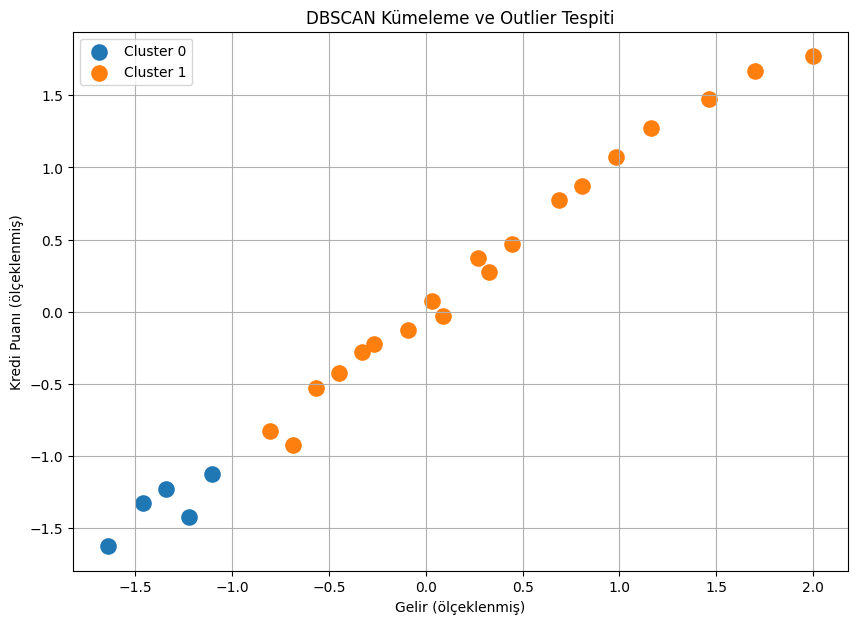

In [12]:
plt.figure(figsize=(10, 7))

unique_labels = set(labels)

for label in unique_labels:
    if label == -1:
        # OUTLIER
        plt.scatter(
            X_scaled[labels == label, 0],
            X_scaled[labels == label, 1],
            s=200,
            marker="x",
            label="Outlier"
        )
    else:
        plt.scatter(
            X_scaled[labels == label, 0],
            X_scaled[labels == label, 1],
            s=120,
            label=f"Cluster {label}"
        )

plt.xlabel("Gelir (ölçeklenmiş)")
plt.ylabel("Kredi Puanı (ölçeklenmiş)")
plt.title("DBSCAN Kümeleme ve Outlier Tespiti")
plt.legend()
plt.grid(True)
plt.show()

DBSCAN ne yaptı?

DBSCAN veri üzerinde:

yoğun bölgeleri cluster yaptı
seyrek noktaları outlier (-1) yaptı

In [13]:
print("Cluster dağılımı:")
print(df["cluster"].value_counts())

Cluster dağılımı:
cluster
1    19
0     5
Name: count, dtype: int64


PARAMETRE ANALİZİ (çok önemli)
eps = 0.8 ne demek?

komşuluk yarıçapı
çok küçük → her şey outlier

çok büyük → tek cluster

min_samples = 3

minimum komşu sayısı
yoğunluk eşiği

???? Parametre değiştirerek test et ???? sonuçları gör ve değerlendir. (eps değerini değiştirerek uygula)

İŞ ZEKÂSI ÇIKARIMI
Cluster’lar:
Cluster 0
orta segment müşteriler
standart kredi verilebilir

DBSCAN algoritması, veri seti üzerinde yoğunluk temelli kümeleme yaparak doğal veri gruplarını belirlemiş ve düşük yoğunluklu bölgelerde bulunan gözlemleri aykırı değer olarak tespit etmiştir. Bu yaklaşım, özellikle finansal veri analizlerinde anormal müşteri davranışlarının belirlenmesi açısından önemli avantaj sağlamaktadır. Elde edilen sonuçlar, DBSCAN algoritmasının yalnızca kümeleme değil, aynı zamanda outlier detection amacıyla da etkili biçimde kullanılabileceğini göstermektedir.

Aşağıdaki kod ile karşılaştırma yapabilirsin . Kmeans ile DBScan ????


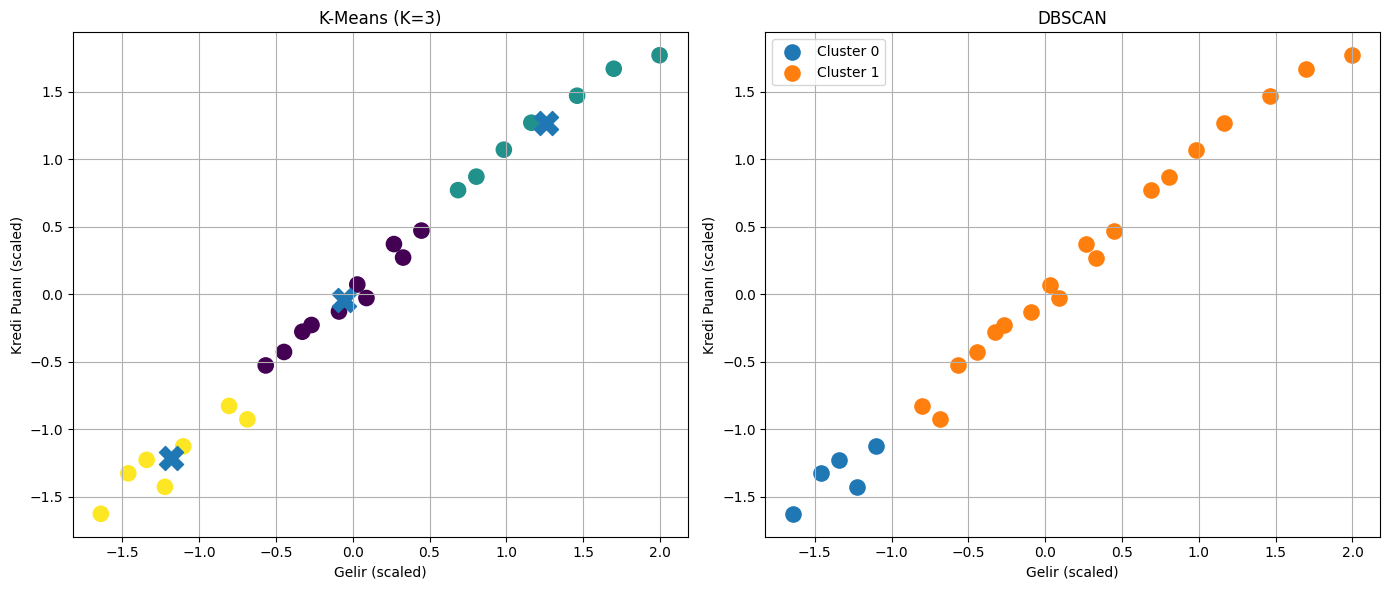

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

# Veri seti
data = {
    "gelir": [32000, 45000, 58000, 62000, 29000, 70000, 52000, 81000, 47000, 90000,
              61000, 38000, 55000, 73000, 34000, 68000, 49000, 76000, 43000, 64000,
              57000, 36000, 85000, 51000],
    "yas": [22, 25, 27, 30, 21, 35, 28, 40, 26, 45,
            31, 24, 29, 38, 23, 34, 27, 39, 25, 33,
            30, 22, 42, 28],
    "mevcut_borc": [18000, 12000, 10000, 9000, 15000, 8000, 14000, 5000, 11000, 4000,
                    9500, 17000, 13000, 6000, 16000, 7000, 12500, 5500, 14500, 8500,
                    10000, 17500, 4500, 13500],
    "kredi_puani": [480, 520, 610, 640, 450, 700, 590, 760, 560, 790,
                    650, 500, 600, 720, 490, 690, 570, 740, 530, 660,
                    620, 470, 780, 585],
    "sonuc": [0, 0, 1, 1, 0, 1, 0, 1, 0, 1,
              1, 0, 1, 1, 0, 1, 0, 1, 0, 1,
              1, 0, 1, 0]
}

df = pd.DataFrame(data)

# Görselleştirme için 2 boyut seçiyoruz
X = df[["gelir", "kredi_puani"]].values

# Ölçekleme (çok önemli!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# K-MEANS
# =========================
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# =========================
# DBSCAN
# =========================
dbscan = DBSCAN(eps=0.4, min_samples=3)
dbscan_labels = dbscan.fit_predict(X_scaled)

# =========================
# GRAFİK
# =========================
plt.figure(figsize=(14,6))

# -------- KMEANS --------
plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=kmeans_labels, s=120)

centers = kmeans.cluster_centers_
plt.scatter(centers[:,0], centers[:,1], marker="X", s=300)

plt.title("K-Means (K=3)")
plt.xlabel("Gelir (scaled)")
plt.ylabel("Kredi Puanı (scaled)")
plt.grid(True)

# -------- DBSCAN --------
plt.subplot(1,2,2)

# Outlier ve cluster ayrımı
unique_labels = set(dbscan_labels)

for label in unique_labels:
    if label == -1:
        # outlier
        plt.scatter(
            X_scaled[dbscan_labels == label, 0],
            X_scaled[dbscan_labels == label, 1],
            s=150,
            marker="x",
            label="Outlier"
        )
    else:
        plt.scatter(
            X_scaled[dbscan_labels == label, 0],
            X_scaled[dbscan_labels == label, 1],
            s=120,
            label=f"Cluster {label}"
        )

plt.title("DBSCAN")
plt.xlabel("Gelir (scaled)")
plt.ylabel("Kredi Puanı (scaled)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()